<a href="https://colab.research.google.com/github/MOHDVAZI4/college_labsheet_computervision/blob/main/labsheet06.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving Screenshot 2026-10-09 231748.png to Screenshot 2026-10-09 231748.png
Image loaded successfully: Screenshot 2026-10-09 231748.png


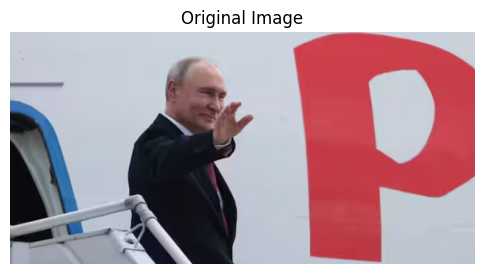

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

from google.colab import files
from sklearn.cluster import KMeans
from skimage import segmentation, color, graph
from skimage.filters import gaussian
from skimage.segmentation import active_contour

# Upload an image
uploaded = files.upload()

filename = next(iter(uploaded))
image = cv2.imread(filename)

if image is None:
    raise ValueError("Could not load image. Please upload a valid image.")

print("Image loaded successfully:", filename)

plt.figure(figsize=(6, 4))
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis("off")
plt.show()

In [2]:
import ipywidgets as widgets
from IPython.display import display

gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

def segment_image(method, threshold, block_size, c_value):
    if method == "Global Binary":
        _, result = cv2.threshold(
            gray, threshold, 255, cv2.THRESH_BINARY
        )

    elif method == "Otsu":
        _, result = cv2.threshold(
            gray, 0, 255,
            cv2.THRESH_BINARY + cv2.THRESH_OTSU
        )

    elif method == "Adaptive Mean":
        result = cv2.adaptiveThreshold(
            gray, 255, cv2.ADAPTIVE_THRESH_MEAN_C,
            cv2.THRESH_BINARY, block_size, c_value
        )

    else:
        result = cv2.adaptiveThreshold(
            gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
            cv2.THRESH_BINARY, block_size, c_value
        )

    plt.figure(figsize=(10, 4))

    plt.subplot(1, 2, 1)
    plt.imshow(gray, cmap="gray")
    plt.title("Original Grayscale")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(result, cmap="gray")
    plt.title("Segmented Image")
    plt.axis("off")

    plt.show()

widgets.interact(
    segment_image,
    method=widgets.Dropdown(
        options=["Global Binary", "Otsu",
                 "Adaptive Mean", "Adaptive Gaussian"]
    ),
    threshold=widgets.IntSlider(
        min=0, max=255, value=127
    ),
    block_size=widgets.IntSlider(
        min=3, max=99, step=2, value=11
    ),
    c_value=widgets.IntSlider(
        min=-20, max=20, value=2
    )
);

interactive(children=(Dropdown(description='method', options=('Global Binary', 'Otsu', 'Adaptive Mean', 'Adapt…

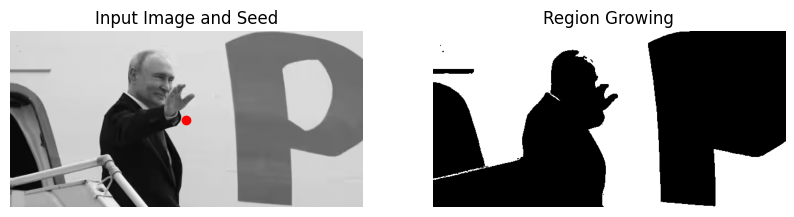

In [3]:
def region_growing(img, seed, threshold=10, connectivity=8):
    h, w = img.shape
    x, y = seed

    if not (0 <= x < w and 0 <= y < h):
        raise ValueError("Seed point is outside the image.")

    segmented = np.zeros((h, w), dtype=np.uint8)
    visited = np.zeros((h, w), dtype=bool)

    seed_value = int(img[y, x])
    queue = [(x, y)]
    visited[y, x] = True

    if connectivity == 4:
        neighbors = [(-1, 0), (1, 0), (0, -1), (0, 1)]
    else:
        neighbors = [
            (-1, 0), (1, 0), (0, -1), (0, 1),
            (-1, -1), (-1, 1), (1, -1), (1, 1)
        ]

    while queue:
        cx, cy = queue.pop(0)
        segmented[cy, cx] = 255

        for dx, dy in neighbors:
            nx, ny = cx + dx, cy + dy

            if 0 <= nx < w and 0 <= ny < h:
                if not visited[ny, nx]:
                    visited[ny, nx] = True

                    if abs(int(img[ny, nx]) - seed_value) <= threshold:
                        queue.append((nx, ny))

    return segmented


gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

seed_x = gray.shape[1] // 2
seed_y = gray.shape[0] // 2

mask = region_growing(
    gray, (seed_x, seed_y), threshold=15, connectivity=8
)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(gray, cmap="gray")
plt.scatter(seed_x, seed_y, color="red")
plt.title("Input Image and Seed")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(mask, cmap="gray")
plt.title("Region Growing")
plt.axis("off")

plt.show()

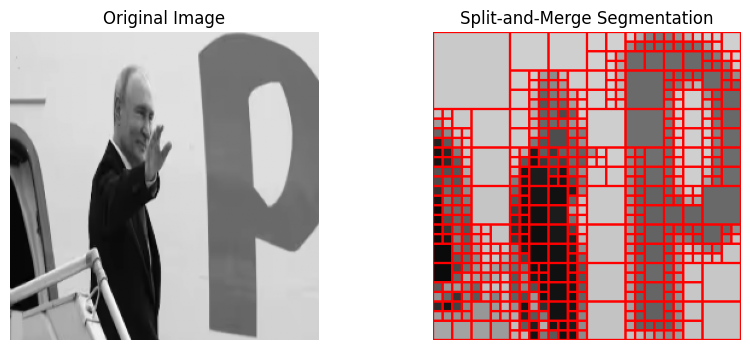

In [4]:
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Resize to a square image
size = min(gray.shape)
size = 2 ** int(np.log2(size))
gray = cv2.resize(gray, (size, size))

def split_merge(img, max_std=15, min_size=8):
    h, w = img.shape
    result = np.zeros_like(img)
    edges = np.zeros_like(img)

    def process(x, y, width, height):
        block = img[y:y+height, x:x+width]

        if block.size == 0:
            return

        std = np.std(block)

        if std > max_std and width > min_size and height > min_size:
            half_w = width // 2
            half_h = height // 2

            process(x, y, half_w, half_h)
            process(x + half_w, y, width - half_w, half_h)
            process(x, y + half_h, half_w, height - half_h)
            process(x + half_w, y + half_h,
                    width - half_w, height - half_h)
        else:
            result[y:y+height, x:x+width] = int(np.mean(block))
            cv2.rectangle(
                edges, (x, y),
                (x + width - 1, y + height - 1),
                255, 1
            )

    process(0, 0, w, h)
    return result, edges


segmented, boundaries = split_merge(gray, max_std=15)

overlay = cv2.cvtColor(segmented, cv2.COLOR_GRAY2RGB)
overlay[boundaries > 0] = [255, 0, 0]

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(gray, cmap="gray")
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(overlay)
plt.title("Split-and-Merge Segmentation")
plt.axis("off")

plt.show()

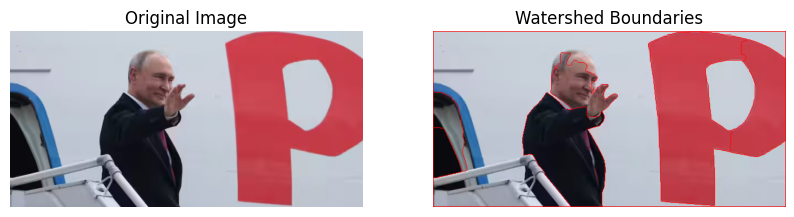

In [5]:
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Binary threshold
_, thresh = cv2.threshold(
    gray, 0, 255,
    cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
)

kernel = np.ones((3, 3), np.uint8)

# Remove noise
opening = cv2.morphologyEx(
    thresh, cv2.MORPH_OPEN, kernel, iterations=2
)

# Sure background
sure_bg = cv2.dilate(opening, kernel, iterations=3)

# Distance transform
dist_transform = cv2.distanceTransform(
    opening, cv2.DIST_L2, 5
)

# Sure foreground
_, sure_fg = cv2.threshold(
    dist_transform,
    0.4 * dist_transform.max(),
    255, 0
)

sure_fg = np.uint8(sure_fg)

# Unknown region
unknown = cv2.subtract(sure_bg, sure_fg)

# Markers
_, markers = cv2.connectedComponents(sure_fg)
markers = markers + 1
markers[unknown == 255] = 0

# Apply watershed
result = image.copy()
markers = cv2.watershed(result, markers)
result[markers == -1] = [0, 0, 255]

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
plt.title("Watershed Boundaries")
plt.axis("off")

plt.show()

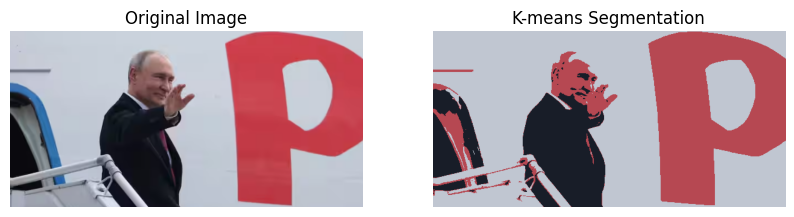

In [6]:
def kmeans_segmentation(img, k=3, color_space="RGB"):
    if color_space == "HSV":
        processed = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    elif color_space == "Lab":
        processed = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    else:
        processed = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    pixels = processed.reshape((-1, 3)).astype(np.float32)

    model = KMeans(
        n_clusters=k, random_state=42, n_init=10
    )
    labels = model.fit_predict(pixels)

    centers = np.uint8(model.cluster_centers_)
    segmented = centers[labels].reshape(processed.shape)

    if color_space == "HSV":
        segmented = cv2.cvtColor(segmented, cv2.COLOR_HSV2RGB)
    elif color_space == "Lab":
        segmented = cv2.cvtColor(segmented, cv2.COLOR_LAB2RGB)

    return segmented


segmented = kmeans_segmentation(image, k=3, color_space="RGB")

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(segmented)
plt.title("K-means Segmentation")
plt.axis("off")

plt.show()

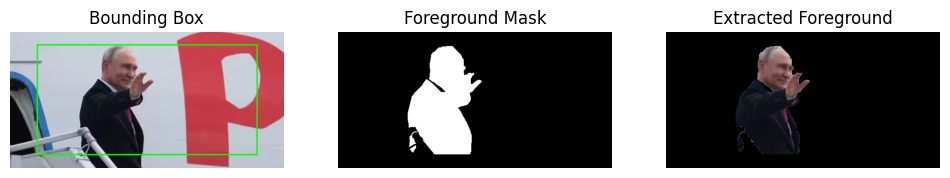

In [7]:
# GrabCut works with a rectangular region around the object
img = image.copy()
h, w = img.shape[:2]

# Define bounding rectangle
x = w // 10
y = h // 10
width = w - 2 * x
height = h - 2 * y

rect = (x, y, width, height)

mask = np.zeros((h, w), np.uint8)
bgd_model = np.zeros((1, 65), np.float64)
fgd_model = np.zeros((1, 65), np.float64)

cv2.grabCut(
    img, mask, rect,
    bgd_model, fgd_model,
    5, cv2.GC_INIT_WITH_RECT
)

# Extract foreground mask
foreground_mask = np.where(
    (mask == cv2.GC_FGD) | (mask == cv2.GC_PR_FGD),
    255, 0
).astype(np.uint8)

foreground = cv2.bitwise_and(
    img, img, mask=foreground_mask
)

# Draw bounding box
boxed = img.copy()
cv2.rectangle(
    boxed, (x, y), (x + width, y + height),
    (0, 255, 0), 2
)

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(boxed, cv2.COLOR_BGR2RGB))
plt.title("Bounding Box")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(foreground_mask, cmap="gray")
plt.title("Foreground Mask")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(cv2.cvtColor(foreground, cv2.COLOR_BGR2RGB))
plt.title("Extracted Foreground")
plt.axis("off")

plt.show()

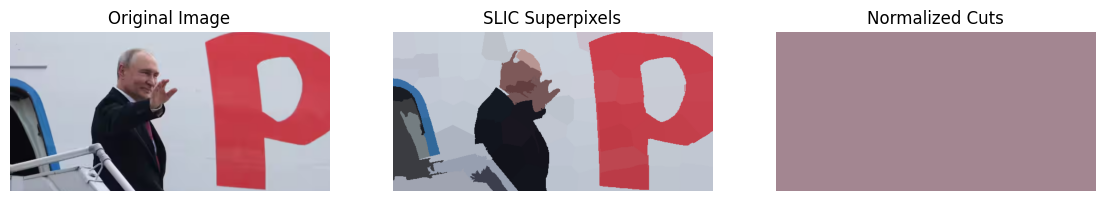

In [8]:
img_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Generate superpixels using SLIC
labels1 = segmentation.slic(
    img_rgb,
    n_segments=100,
    compactness=10,
    start_label=1,
    channel_axis=-1
)

# Build Region Adjacency Graph
rag = graph.rag_mean_color(img_rgb, labels1)

# Apply normalized cut
labels2 = graph.cut_normalized(
    labels1, rag, thresh=0.01
)

# Display segmented regions
superpixels = color.label2rgb(
    labels1, img_rgb, kind="avg"
)

normalized_result = color.label2rgb(
    labels2, img_rgb, kind="avg"
)

plt.figure(figsize=(14, 4))

plt.subplot(1, 3, 1)
plt.imshow(img_rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(superpixels)
plt.title("SLIC Superpixels")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(normalized_result)
plt.title("Normalized Cuts")
plt.axis("off")

plt.show()

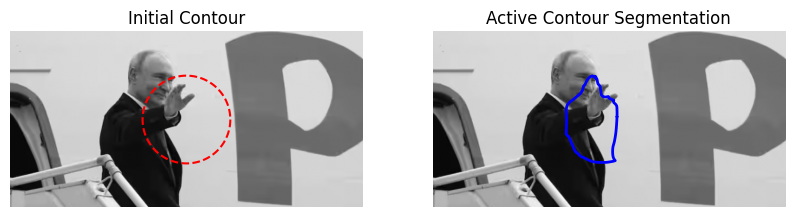

In [9]:
# Convert to grayscale
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Smooth the image
smooth_img = gaussian(
    gray, sigma=2, preserve_range=True
)

h, w = gray.shape

# Initial circular contour
center_x = w // 2
center_y = h // 2
radius = min(h, w) // 4

theta = np.linspace(0, 2 * np.pi, 100)

init_x = center_x + radius * np.cos(theta)
init_y = center_y + radius * np.sin(theta)

initial_contour = np.array(
    [init_y, init_x]
).T

# Apply active contour
snake = active_contour(
    smooth_img,
    initial_contour,
    alpha=0.015,
    beta=10,
    w_line=0,
    w_edge=1,
    max_num_iter=250
)

# Display result
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(gray, cmap="gray")
plt.plot(initial_contour[:, 1], initial_contour[:, 0], "--r")
plt.title("Initial Contour")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(gray, cmap="gray")
plt.plot(snake[:, 1], snake[:, 0], "-b", linewidth=2)
plt.title("Active Contour Segmentation")
plt.axis("off")

plt.show()

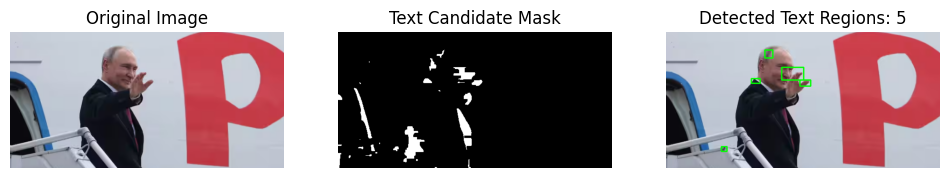

In [10]:
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Highlight dark text on a light background
kernel = cv2.getStructuringElement(
    cv2.MORPH_RECT, (17, 5)
)

blackhat = cv2.morphologyEx(
    gray, cv2.MORPH_BLACKHAT, kernel
)

# Calculate horizontal gradients
grad_x = cv2.Sobel(
    blackhat, cv2.CV_32F,
    dx=1, dy=0, ksize=-1
)

grad_x = np.abs(grad_x)

# Normalize gradient
grad_x = cv2.normalize(
    grad_x, None, 0, 255, cv2.NORM_MINMAX
).astype(np.uint8)

# Blur and threshold
grad_x = cv2.GaussianBlur(grad_x, (5, 5), 0)

_, thresh = cv2.threshold(
    grad_x, 0, 255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

# Join nearby text regions
thresh = cv2.morphologyEx(
    thresh, cv2.MORPH_CLOSE, kernel
)

# Find contours
contours, _ = cv2.findContours(
    thresh, cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

output = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
count = 0

for contour in contours:
    x, y, w, h = cv2.boundingRect(contour)
    area = w * h
    aspect_ratio = w / float(h)

    if area > 100 and 1.0 <= aspect_ratio <= 15.0:
        cv2.rectangle(
            output, (x, y), (x + w, y + h),
            (0, 255, 0), 2
        )
        count += 1

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(thresh, cmap="gray")
plt.title("Text Candidate Mask")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(output)
plt.title(f"Detected Text Regions: {count}")
plt.axis("off")

plt.show()

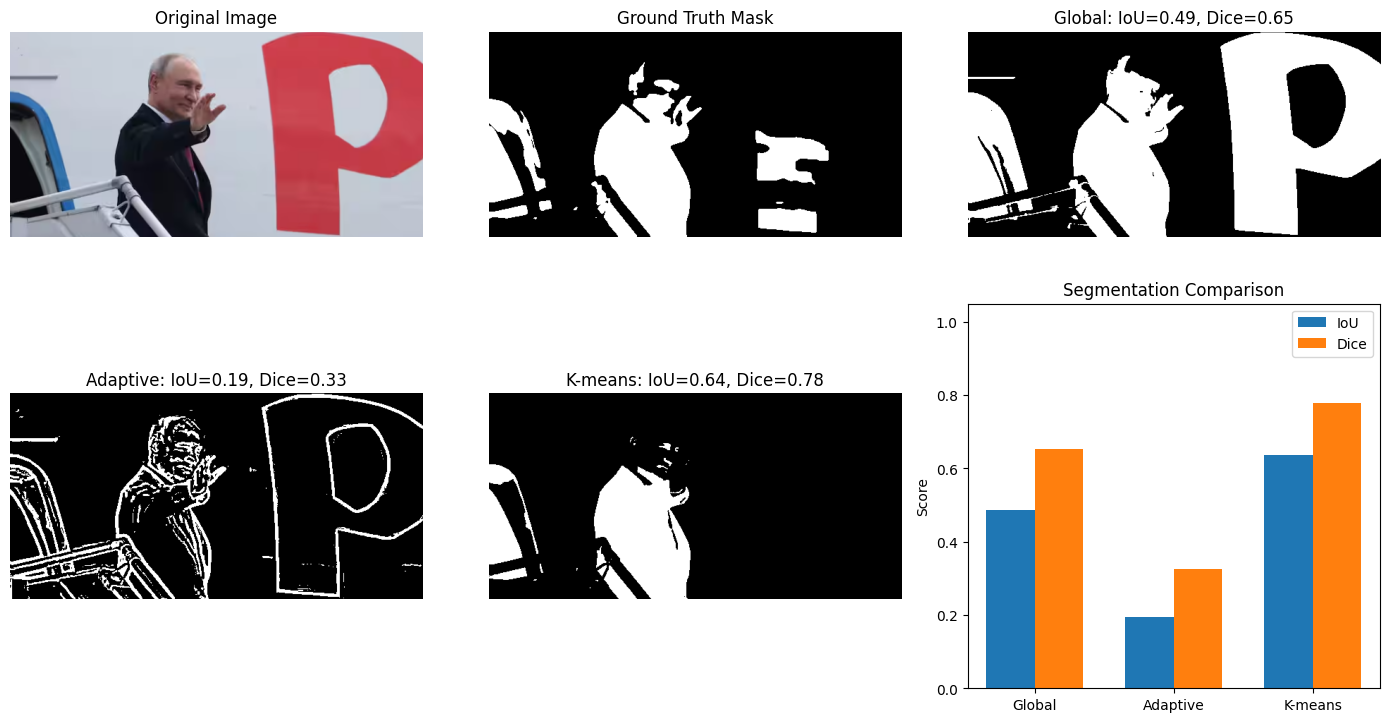

In [11]:
def calculate_metrics(pred_mask, gt_mask):
    pred = (pred_mask > 0).astype(np.uint8)
    gt = (gt_mask > 0).astype(np.uint8)

    intersection = np.sum(pred & gt)
    union = np.sum(pred | gt)

    iou = intersection / union if union > 0 else 1.0

    total = np.sum(pred) + np.sum(gt)
    dice = (2 * intersection / total) if total > 0 else 1.0

    return iou, dice


gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Method A: Global thresholding
_, mask_thresh = cv2.threshold(
    gray, 127, 255, cv2.THRESH_BINARY_INV
)

# Method B: Adaptive thresholding
mask_adaptive = cv2.adaptiveThreshold(
    gray, 255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY_INV, 11, 2
)

# Method C: K-means grayscale segmentation
pixels = gray.reshape(-1, 1).astype(np.float32)

model = KMeans(
    n_clusters=3, random_state=42, n_init=10
)
labels = model.fit_predict(pixels)

cluster_means = [
    pixels[labels == i].mean()
    for i in range(3)
]

darkest_cluster = np.argmin(cluster_means)

mask_kmeans = np.where(
    labels.reshape(gray.shape) == darkest_cluster,
    255, 0
).astype(np.uint8)

# Demonstration ground-truth mask.
# Replace this with a real manually annotated mask
# for meaningful accuracy evaluation.
blurred = cv2.GaussianBlur(gray, (9, 9), 0)

_, gt_mask = cv2.threshold(
    blurred, 100, 255, cv2.THRESH_BINARY_INV
)

# Calculate IoU and Dice
iou_t, dice_t = calculate_metrics(mask_thresh, gt_mask)
iou_a, dice_a = calculate_metrics(mask_adaptive, gt_mask)
iou_k, dice_k = calculate_metrics(mask_kmeans, gt_mask)

methods = ["Global", "Adaptive", "K-means"]
iou_scores = [iou_t, iou_a, iou_k]
dice_scores = [dice_t, dice_a, dice_k]

# Display images and scores
plt.figure(figsize=(14, 8))

plt.subplot(2, 3, 1)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(gt_mask, cmap="gray")
plt.title("Ground Truth Mask")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(mask_thresh, cmap="gray")
plt.title(f"Global: IoU={iou_t:.2f}, Dice={dice_t:.2f}")
plt.axis("off")

plt.subplot(2, 3, 4)
plt.imshow(mask_adaptive, cmap="gray")
plt.title(f"Adaptive: IoU={iou_a:.2f}, Dice={dice_a:.2f}")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(mask_kmeans, cmap="gray")
plt.title(f"K-means: IoU={iou_k:.2f}, Dice={dice_k:.2f}")
plt.axis("off")

# Comparison chart
x = np.arange(len(methods))
width = 0.35

plt.subplot(2, 3, 6)
plt.bar(x - width/2, iou_scores, width, label="IoU")
plt.bar(x + width/2, dice_scores, width, label="Dice")

plt.xticks(x, methods)
plt.ylim(0, 1.05)
plt.ylabel("Score")
plt.title("Segmentation Comparison")
plt.legend()

plt.tight_layout()
plt.show()